## Project Initialization & Data Loading

In this section, we will prepare our working environment by importing the necessary libraries for data manipulation and visualization. Afterward, we will load our primary dataset for analysis.

### 1. Importing Libraries
We will utilize the following core libraries:
* **`pandas`**: For data structures and data analysis tasks.
* **`seaborn` & `matplotlib`**: For creating informative and interactive visualizations.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
from sklearn.model_selection import train_test_split

### 2. Loading Dataset
We are loading the `surat_uncleaned.csv` file, which contains the raw property data we will be working with throughout this project.

In [2]:

# Load the dataset
df = pd.read_csv('C:/Users/aotha/OneDrive/Reggration/سكاشن/project/surat_uncleaned.csv')

## Initial Data Inspection

The `df.head()` execution provides an immediate snapshot of our raw dataset, revealing several key observations:

* **Feature Structure:** The dataset consists of 11 columns, including property details (`property_name`, `areaWithType`), location-specific data (`facing`), and pricing information (`price`, `price_per_sqft`).
* **Data Quality Issues:**
    * **Non-Numeric formats:** Key columns such as `price` and `price_per_sqft` contain mixed characters (e.g., "Lac", "₹", "per sqft"), confirming they are currently stored as object types rather than numeric.
    * **Data Sparsity:** Columns like `description` and `furnishing` already show initial signs of missing information, which will need to be addressed in our cleaning pipeline.

In [3]:

# Display the first 5 rows to get a quick glance
df.head()

,property_name,areaWithType,square_feet,transaction,status,floor,furnishing,facing,description,price_per_sqft,price
0,2 BHK Apartment for Sale in Dindoli Surat,Carpet Area,644 sqft,New Property,Poss. by Oct '24,5 out of 10,Unfurnished,West,"Luxury project with basement parking, Solar ro...","₹2,891 per sqft",₹33.8 Lac
1,2 BHK Apartment for Sale in Althan Surat,Super Area,1278 sqft,New Property,Poss. by Jan '26,6 out of 14,Unfurnished,South -West,2 And 3 BHK Luxurious Flat for Sell In New Alt...,"₹3,551 per sqft",₹45.4 Lac
2,2 BHK Apartment for Sale in Pal Gam Surat,Super Area,1173 sqft,Resale,Ready to Move,5 out of 13,Semi-Furnished,East,This affordable 2 BHK flat is situated along a...,"₹3,800 per sqft",₹44.6 Lac
3,2 BHK Apartment for Sale in Jahangirabad Surat,Carpet Area,700 sqft,New Property,Ready to Move,6 out of 14,Unfurnished,East,2 BHK Flat For sell IN Jahangirabad Prime Loca...,"₹3,966 per sqft",₹47 Lac
4,"2 BHK Apartment for Sale in Orchid Fantasia, P...",Super Area,1250 sqft,Orchid Fantasia,New Property,Unfurnished,2,2,"Multistorey Apartment for Sale in Palanpur, Su...","₹3,600 per sqft",₹45 Lac


## Data Structure & Memory Audit

The `df.info()` execution provides a technical audit of our dataset's current state, highlighting critical areas for our cleaning pipeline:

* **Memory Efficiency:** The dataset occupies approximately 389 KB, which is well-managed for our current analysis.
* **Feature Types:** All 11 columns are currently interpreted as `object` types. This confirms that even numeric-looking data (like `price` and `square_feet`) is being treated as text, necessitating manual conversion.
* **Data Completeness:** The `RangeIndex` of 4525 entries vs. the non-null counts (e.g., `facing` at 3936) clearly quantifies the missing data gaps across different features.
* **Duplicate Detection:** The `df.duplicated().sum()` command reveals redundant entries that will be handled to ensure model accuracy and prevent bias in our regression results.

In [4]:
# Check data structure, column names, and data types
df.info()
# Check for duplicates
print(f"\nNumber of duplicated rows: {df.duplicated().sum()}")

<class 'pandas.DataFrame'>
RangeIndex: 4525 entries, 0 to 4524
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   property_name   4525 non-null   str  
 1   areaWithType    4525 non-null   str  
 2   square_feet     4525 non-null   str  
 3   transaction     4421 non-null   str  
 4   status          4524 non-null   str  
 5   floor           4480 non-null   str  
 6   furnishing      4185 non-null   str  
 7   facing          3936 non-null   str  
 8   description     3154 non-null   str  
 9   price_per_sqft  4157 non-null   str  
 10  price           4525 non-null   str  
dtypes: str(11)
memory usage: 389.0 KB

Number of duplicated rows: 109


## Missing Data Analysis Findings

After performing a comprehensive missing data analysis, we identified key features requiring **data preprocessing**. Specifically, the analysis highlights the following:

* **High Sparsity Detected:** Features such as `description` and `facing` exhibit the highest degree of missing values.
* **Strategic Next Steps:** To maintain dataset integrity, we will implement **imputation strategies** for these features rather than simple deletion, ensuring our regression model has enough data to learn patterns effectively.

In [5]:
# Calculate total missing values for each column
missing_values = df.isnull().sum()
# Display columns with missing values in descending order
print("Missing values per column:")
print(missing_values[missing_values > 0].sort_values(ascending=False))

Missing values per column:
description       1371
facing             589
price_per_sqft     368
furnishing         340
transaction        104
floor               45
status               1
dtype: int64


## Missing Data Visualization Analysis

The bar plot above provides a clear visual representation of data sparsity across our dataset. Based on the output, we can conclude the following:

* **High-Impact Features:** Columns like `description`, `facing`, and `price_per_sqft` show the highest counts of missing data. These features require immediate attention—either through **imputation** (filling missing values) or **exclusion** if the data is too sparse to be reliable.
* **Data Integrity:** Columns with minimal missing entries can be easily handled, ensuring that we maintain a robust dataset size for our regression modeling.
* **Cleaning Priorities:** This visualization serves as our "priority list" for the cleaning phase, guiding us on which variables need the most significant preprocessing effort.

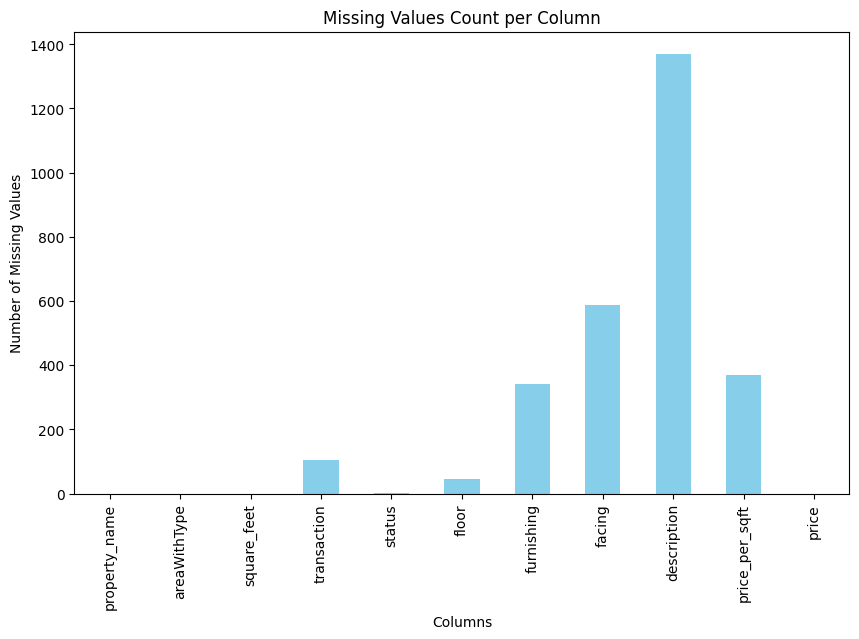

In [6]:
# Create a bar plot to visualize missing values
# This helps us identify which features require cleaning or imputation
plt.figure(figsize=(10, 6))
missing_values.plot(kind='bar', color='skyblue')
# Add labels and title for clarity
plt.title('Missing Values Count per Column')
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
# Display the plot
plt.show()

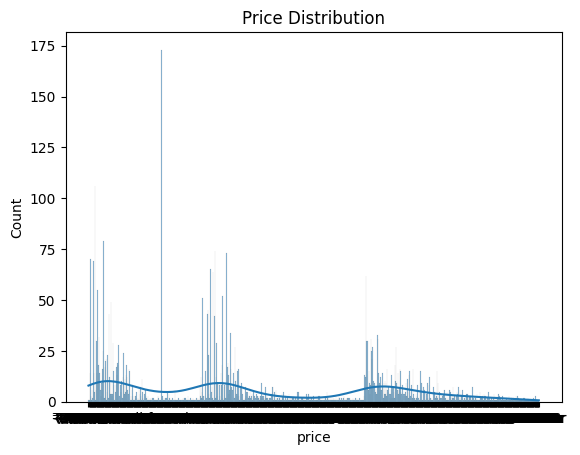

In [7]:
sns.histplot(df['price'], kde=True)
plt.title("Price Distribution")
plt.show()

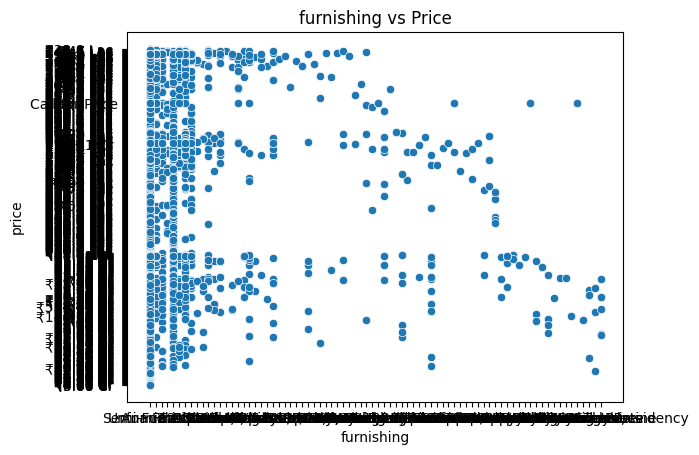

In [8]:
sns.scatterplot(x='furnishing', y='price', data=df)
plt.title("furnishing vs Price")
plt.show()

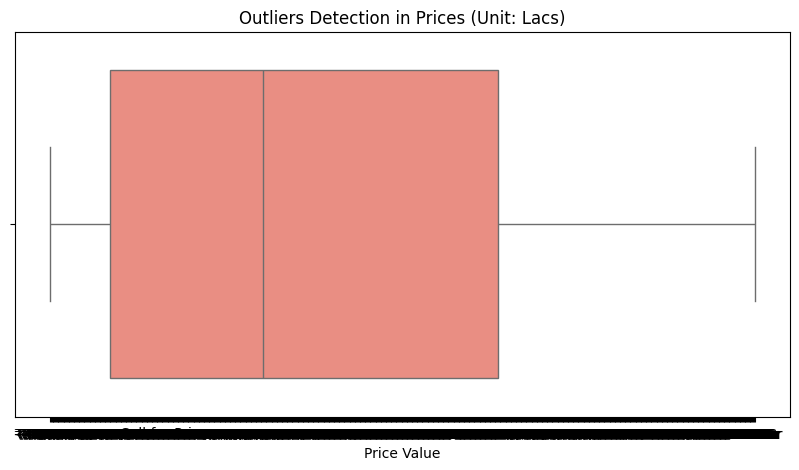

In [9]:
# رسم الـ Box Plot
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['price'], color='salmon')
plt.title('Outliers Detection in Prices (Unit: Lacs)')
plt.xlabel('Price Value')
plt.show()

## Data Quality Inspection: Formatting Audit

In this step, we performed a targeted inspection of the most critical numerical features: `price` and `square_feet`. The objective was to verify the consistency of the data entries.

* **Key Findings:** * The inspection confirms that both features currently store numeric data as string/object formats, mixed with currency symbols, unit labels (e.g., "Lac", "sqft"), and non-standard text (e.g., "Call for Price").
* **Impact:** This formatting prevents direct mathematical operations, making it impossible to calculate correlations or train regression models without prior transformation.
* **Action Plan:** We have identified these as high-priority targets for our `Data Cleaning` pipeline, where we will implement automated parsing functions to extract clean, numeric values.

In [10]:
# Inspecting price and square_feet columns to identify the 'dirty' formatting
print("--- Sample data from 'price' column ---")
print(df['price'].head(10))

print("\n--- Sample data from 'square_feet' column ---")
print(df['square_feet'].head(10))

--- Sample data from 'price' column ---
0    ₹33.8 Lac 
1    ₹45.4 Lac 
2    ₹44.6 Lac 
3      ₹47 Lac 
4      ₹45 Lac 
5    ₹43.2 Lac 
6    ₹42.1 Lac 
7    ₹44.1 Lac 
8    ₹44.3 Lac 
9      ₹40 Lac 
Name: price, dtype: str

--- Sample data from 'square_feet' column ---
0     644 sqft
1    1278 sqft
2    1173 sqft
3     700 sqft
4    1250 sqft
5    1265 sqft
6    1404 sqft
7     700 sqft
8    1180 sqft
9     720 sqft
Name: square_feet, dtype: str


## Data Cleaning Pipeline

Based on our exploratory findings, we have identified several issues that need to be addressed before building our regression model. The primary focus of this cleaning stage is to:

* **Type Conversion:** Convert columns like `price` and `square_feet` from object/text formats to numeric types to allow for mathematical modeling.
* **Feature Refinement:** Remove non-predictive features (e.g., `description`, `property_name`) that do not contribute to our price prediction analysis.
* **Standardization:** Ensure all numeric columns are correctly formatted and cleaned of currency symbols or unit labels.

The following code implements these transformations to prepare our dataset for the modeling phase.

In [11]:
# ============================================================
# 3. تنظيف عمود السعر (price) – هذه هي المشكلة الأساسية التي أصلحناها
# ============================================================
def clean_price(price_str):
    """
    تحويل "33.8 Lac" إلى 3,380,000 و "1 Cr" إلى 10,000,000
    """
    if pd.isna(price_str) or str(price_str).strip() == 'Call for Price':
        return None
    price_str = str(price_str).strip()
    # استخراج الرقم (يدعم الأعداد العشرية)
    match = re.search(r'([\d\.]+)', price_str)
    if not match:
        return None
    num = float(match.group(1))
    # تحديد الوحدة
    if 'Cr' in price_str or 'crore' in price_str.lower():
        return num * 10_000_000
    else:  # Lac أو لا توجد وحدة
        return num * 100_000

df['price_cleaned'] = df['price'].apply(clean_price)


### Cleaning the `square_feet` Column

In this step, we clean the `square_feet` column to extract only the numerical values from mixed text formats.

A custom function `clean_square_feet` is used to:

* Handle missing values by returning `None`
* Use regular expressions (regex) to extract numeric values from strings
* Convert the extracted values into float format

Finally, a new column `sqft_cleaned` is created to store the cleaned numerical data, which will be used later in analysis and modeling.


In [12]:
# ============================================================
# 4. تنظيف عمود المساحة (square_feet)
# ============================================================
def clean_square_feet(s):
    if pd.isna(s):
        return None
    match = re.search(r'([\d\.]+)', str(s))
    return float(match.group(1)) if match else None

df['sqft_cleaned'] = df['square_feet'].apply(clean_square_feet)


### Cleaning the `price_per_sqft` Column

In this step, we clean the `price_per_sqft` column to extract numerical values from mixed text data.

A custom function `clean_price_per_sqft` is applied to:

* Handle missing values by returning `None`
* Use regular expressions (regex) to extract numeric values from strings
* Convert the extracted values into float format

The cleaned values are then stored in a new column `price_per_sqft_cleaned`, which will be used for further analysis and modeling.


In [13]:
# ============================================================
# 5. تنظيف عمود السعر للقدم المربع (price_per_sqft)
# ============================================================
def clean_price_per_sqft(s):
    if pd.isna(s):
        return None
    match = re.search(r'([\d\.]+)', str(s))
    return float(match.group(1)) if match else None

df['price_per_sqft_cleaned'] = df['price_per_sqft'].apply(clean_price_per_sqft)


### Cleaning the `floor` Column

In this step, we clean the `floor` column by extracting only the first numerical value from the text.

The `clean_floor` function is used to:

* Handle missing values by returning `None`
* Use regular expressions (regex) to extract the first integer found in the string
* Convert the extracted value into an integer

If no number is found, the function returns `0` as a default value.
The cleaned data is then stored in a new column called `floor_cleaned` for further use in analysis and modeling.


In [14]:
# ============================================================
# 6. تنظيف عمود الدور (floor) – استخراج الرقم الأول فقط
# ============================================================
def clean_floor(s):
    if pd.isna(s):
        return None
    match = re.search(r'(\d+)', str(s))
    return int(match.group(1)) if match else 0

df['floor_cleaned'] = df['floor'].apply(clean_floor)

### Dropping Unnecessary Columns

In this step, we remove columns that are no longer needed for analysis and modeling.

These columns include:

* Text-heavy columns that are not useful for numerical analysis (e.g., `description`, `property_name`)
* Original columns that have already been cleaned and replaced with processed versions (e.g., `square_feet`, `price_per_sqft`, `floor`)
* Redundant or unstructured columns (e.g., `areaWithType`, `price`)

Dropping these columns helps simplify the dataset, reduce noise, and improve model performance.


In [15]:
# ============================================================
# 7. إسقاط الأعمدة غير الضرورية
# ============================================================
df = df.drop(['description', 'property_name', 'areaWithType', 
              'price', 'square_feet', 'price_per_sqft', 'floor'], axis=1)

### Removing Rows with Missing Target Values

In this step, we remove rows where the target variable (`price_cleaned`) is missing.

Since the price is the main variable we want to predict, any row without a valid price cannot be used for training the model.

We use `dropna` to:

* Remove rows with missing values in the target column
* Create a clean copy of the dataset (`df_clean`) for further processing

Finally, we print the number of remaining rows to track how much data is left after cleaning.


In [16]:
# ============================================================
# 8. إزالة الصفوف التي فشل تنظيف السعر (الهدف لا يمكن استخدامه)
# ============================================================
df_clean = df.dropna(subset=['price_cleaned']).copy()
print(f"After removing rows with missing price: {len(df_clean)}")

After removing rows with missing price: 4352


### Splitting Features and Target Variable

In this step, we separate the dataset into input features (X) and the target variable (y).

* `X` contains all the independent variables (features) that will be used to make predictions.
* `y` contains the dependent variable (`price_cleaned`), which is the value we want to predict.

This separation is an essential step before training any machine learning model.


In [17]:
# ============================================================
# 9. تقسيم البيانات إلى X (ميزات) و y (هدف)
# ============================================================
X = df_clean.drop('price_cleaned', axis=1)
y = df_clean['price_cleaned']

### Train-Test Split

In this step, we split the dataset into training and testing sets using an 80/20 ratio.

* The training set (80%) is used to train the model.
* The testing set (20%) is used to evaluate the model’s performance on unseen data.

We perform this split **before any further preprocessing** to avoid data leakage and ensure a fair evaluation.

A fixed `random_state` is used to make the results reproducible.


In [ ]:
# ============================================================
# 10. تقسيم Train/Test (80/20) – قبل أي معالجة إضافية
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, ليه بنقسم الداتا 80و20
    X
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 3481, Test size: 871


### Cleaning Categorical Columns (Removing Invalid Values)

In this step, we clean the categorical features by keeping only valid and consistent values.

We define a list of allowed values for each categorical column such as:

* `furnishing`
* `facing`
* `transaction`

Then, we:

* Check the current unique values before cleaning (for inspection)
* Create a mask to filter only rows that contain valid values
* Apply this mask to both training and testing sets (`X_train`, `X_test`) as well as their corresponding targets (`y_train`, `y_test`)

This ensures that:

* All categorical data is consistent
* No unexpected or noisy values are included in the model

Finally, we print the dataset size before and after cleaning to track how many rows were removed, and verify that only valid values remain.


In [19]:
# ============================================================
# 10.5 CLEAN CATEGORICAL COLUMNS (Remove invalid values)
# ============================================================

# Define valid values for each categorical column
valid_furnishing = ['Unfurnished', 'Furnished', 'Semi-Furnished']
valid_facing = ['East', 'West', 'North', 'South', 'North-East', 'North-West', 'South-East', 'South-West']
valid_transaction = ['New Property', 'Resale']
valid_status = ['Ready to Move']  # Add more if needed, e.g., 'Poss. by ...' but we'll keep simple

print("\n" + "="*60)
print("CLEANING CATEGORICAL COLUMNS")
print("="*60)

# Check current unique values before cleaning (for reporting)
print("\nBefore cleaning - Unique values in categorical columns:")
print(f"furnishing: {X_train['furnishing'].unique()[:10]}...")
print(f"facing: {X_train['facing'].unique()[:10]}...")
print(f"transaction: {X_train['transaction'].unique()[:10]}...")

# Function to create mask for valid rows
def get_valid_mask(df):
    mask = (
        df['furnishing'].isin(valid_furnishing) &
        df['facing'].isin(valid_facing) &
        df['transaction'].isin(valid_transaction)
    )
    # Optional: also check status if needed
    # & df['status'].isin(valid_status)
    return mask

# Get masks for train and test
train_mask = get_valid_mask(X_train)
test_mask = get_valid_mask(X_test)

print(f"\nRows before cleaning:")
print(f"X_train: {len(X_train)} rows")
print(f"X_test: {len(X_test)} rows")

# Apply masks to X_train, X_test, y_train, y_test
X_train = X_train[train_mask].copy()
y_train = y_train[train_mask].copy()
X_test = X_test[test_mask].copy()
y_test = y_test[test_mask].copy()

print(f"\nRows after cleaning (removing invalid categorical values):")
print(f"X_train: {len(X_train)} rows")
print(f"X_test: {len(X_test)} rows")
print(f"Rows removed from train: {train_mask.size - train_mask.sum()}")
print(f"Rows removed from test: {test_mask.size - test_mask.sum()}")

# Verify no invalid values remain
print("\nAfter cleaning - Unique values in categorical columns:")
print(f"furnishing: {X_train['furnishing'].unique()}")
print(f"facing: {X_train['facing'].unique()}")
print(f"transaction: {X_train['transaction'].unique()}")


CLEANING CATEGORICAL COLUMNS

Before cleaning - Unique values in categorical columns:
furnishing: <StringArray>
[           'Unfurnished',         'Semi-Furnished',                      nan,
               'Ambience',                   'East',              'Furnished',
 'Green Valley Row House',                      '7',           'North - East',
                      '1']
Length: 10, dtype: str...
facing: <StringArray>
[        'West',            '2',         'East',            nan,
  'South -West',            '4',    'Main Road', 'South - East',
            '3',  'Garden/Park']
Length: 10, dtype: str...
transaction: <StringArray>
[        'New Property',               'Resale',                    nan,
          'Unfurnished',       'Semi-Furnished', 'Co-operative Society',
                    '2',                    '1',            'Furnished',
                'Congo']
Length: 10, dtype: str...

Rows before cleaning:
X_train: 3481 rows
X_test: 871 rows

Rows after cleaning (removing

### Handling Missing Values (Imputation Setup)

In this step, we prepare for handling missing values by identifying numerical and categorical columns.

* `numeric_cols` includes continuous features such as area, price per square foot, and floor.
* `categorical_cols` includes categorical features such as transaction type, status, furnishing, and facing.

This separation is important because different imputation strategies are applied:

* Numerical features are typically filled using statistical values (e.g., mean or median)
* Categorical features are usually filled using the most frequent value (mode)

Imputation will be performed using only the training data to avoid data leakage.


In [20]:
# ============================================================
# 11. التعامل مع القيم المفقودة (Imputation) – من Train فقط
# ============================================================
# تحديد الأعمدة الرقمية والفئوية
numeric_cols = ['sqft_cleaned', 'price_per_sqft_cleaned', 'floor_cleaned']
categorical_cols = ['transaction', 'status', 'furnishing', 'facing']

### Imputing Missing Numerical Values

In this step, we handle missing values in numerical features using the median.

* We calculate the median of each numerical column from the training set only
* Then, we fill missing values in both `X_train` and `X_test` using these median values

Using the median is preferred because it is less sensitive to outliers compared to the mean.

Applying the same values from the training set to the test set ensures consistency and prevents data leakage.


In [21]:
# تعويض الرقمية بالوسيط (median)
medians = X_train[numeric_cols].median()
X_train[numeric_cols] = X_train[numeric_cols].fillna(medians)
X_test[numeric_cols] = X_test[numeric_cols].fillna(medians)

### Imputing Missing Categorical Values

In this step, we handle missing values in categorical features using the most frequent value (mode).

For each categorical column:

* We compute the mode from the training set
* Then, we fill missing values in both `X_train` and `X_test` using this mode

Using the most frequent value helps preserve the most common category in the data.

As with numerical imputation, we rely only on the training data to avoid data leakage and ensure consistency.


In [22]:
# تعويض الفئوية بالقيمة الأكثر تكراراً (mode)
for col in categorical_cols:
    mode_val = X_train[col].mode()[0]
    X_train[col] = X_train[col].fillna(mode_val)
    X_test[col] = X_test[col].fillna(mode_val)

### Removing Outliers from Training Data

In this step, we remove outliers from the training data using the Interquartile Range (IQR) method.

For each numerical column:

* We calculate the first quartile (Q1) and third quartile (Q3)
* Compute the IQR as (Q3 - Q1)
* Define lower and upper bounds using 1.5 × IQR

Rows that fall outside these bounds in any numerical column are considered outliers and are removed.

This process is applied only to the training data to:

* Improve model performance
* Prevent the model from being affected by extreme values

The target variable (`y_train`) is filtered accordingly to maintain alignment with the features.


In [23]:
# ============================================================
# 12. إزالة الـ Outliers من بيانات التدريب فقط (اختياري، يمكن تعديل العامل)
# ============================================================
# نطبق IQR على كل عمود رقمي على حدة، ونحذف الصف الذي يحتوي outlier في أي عمود
# (يمكن أيضاً أن نحذف فقط إذا كان outlier في عمود معين، حسب الحاجة)
mask = pd.Series(True, index=X_train.index)
for col in numeric_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    mask &= (X_train[col] >= lower) & (X_train[col] <= upper)

X_train = X_train[mask]
y_train = y_train[mask]
print(f"Train rows after outlier removal: {len(X_train)}")


Train rows after outlier removal: 1206


### Encoding Categorical Variables (One-Hot Encoding)

In this step, we convert categorical features into numerical format using One-Hot Encoding.

* We apply `get_dummies` on both training and testing sets
* `drop_first=True` is used to avoid multicollinearity (dummy variable trap)

To ensure consistency between train and test:

* We add any missing columns in `X_test` that exist in `X_train`
* Remove any extra columns from `X_test`
* Reorder columns in `X_test` to match `X_train`

Finally, we convert boolean columns into integers (0 and 1) to ensure compatibility with machine learning models.


In [24]:
# ============================================================
# 13. ترميز المتغيرات الفئوية (One-Hot Encoding) – بعد التعويض
# ============================================================
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# التأكد من أن train و test لهما نفس الأعمدة
missing_cols = set(X_train_encoded.columns) - set(X_test_encoded.columns)
for col in missing_cols:
    X_test_encoded[col] = 0
# إزالة الأعمدة الزائدة في test
extra_cols = set(X_test_encoded.columns) - set(X_train_encoded.columns)
X_test_encoded = X_test_encoded.drop(columns=extra_cols)
# ترتيب الأعمدة بنفس ترتيب train
X_test_encoded = X_test_encoded[X_train_encoded.columns]

# تحويل bool إلى int (للتأكد)
bool_cols_train = X_train_encoded.select_dtypes(include='bool').columns
X_train_encoded[bool_cols_train] = X_train_encoded[bool_cols_train].astype(int)
bool_cols_test = X_test_encoded.select_dtypes(include='bool').columns
X_test_encoded[bool_cols_test] = X_test_encoded[bool_cols_test].astype(int)


### Inspecting Encoded Data (Optional Visualization)

In this step, we explore the dataset after applying One-Hot Encoding to ensure everything is correct.

We perform several checks:

* Display the shape of the encoded training and testing sets
* Show a sample of column names to understand how categorical variables were transformed
* Preview the first few rows of both `X_train_encoded` and `X_test_encoded`
* Check the data types to confirm that all features are numerical (int or float)

This step helps verify that the encoding process was successful and that the data is ready for model training.


In [25]:
# ============================================================
# 13.5 VISUALIZE ENCODED DATA (Optional)
# ============================================================

print("\n" + "="*60)
print("ENCODED DATA SAMPLE")
print("="*60)

# 1. Print shape of encoded data
print(f"\nShape after encoding:")
print(f"X_train_encoded: {X_train_encoded.shape}")
print(f"X_test_encoded: {X_test_encoded.shape}")

# 2. Print column names (first 20 to avoid clutter)
print(f"\nFirst 20 column names after encoding:")
print(X_train_encoded.columns[:20].tolist())

# 3. Print first 5 rows of encoded training data
print(f"\nFirst 5 rows of X_train_encoded:")
print(X_train_encoded.head())

# 4. Print first 5 rows of encoded test data
print(f"\nFirst 5 rows of X_test_encoded:")
print(X_test_encoded.head())

# 5. Check data types (should be all int/float)
print(f"\nData types in X_train_encoded:")
print(X_train_encoded.dtypes.value_counts())


ENCODED DATA SAMPLE

Shape after encoding:
X_train_encoded: (1206, 42)
X_test_encoded: (341, 42)

First 20 column names after encoding:
['sqft_cleaned', 'price_per_sqft_cleaned', 'floor_cleaned', 'transaction_Resale', "status_Poss. by Apr '26", "status_Poss. by Apr '27", "status_Poss. by Aug '24", "status_Poss. by Aug '25", "status_Poss. by Aug '26", "status_Poss. by Dec '24", "status_Poss. by Dec '25", "status_Poss. by Dec '26", "status_Poss. by Dec '27", "status_Poss. by Feb '25", "status_Poss. by Feb '26", "status_Poss. by Jan '25", "status_Poss. by Jan '26", "status_Poss. by Jan '27", "status_Poss. by Jul '24", "status_Poss. by Jul '25"]

First 5 rows of X_train_encoded:
      sqft_cleaned  price_per_sqft_cleaned  floor_cleaned  transaction_Resale  \
1337         659.0                     2.0            8.0                   0   
322         1075.0                     2.0            6.0                   1   
4341        3113.0                     6.0            8.0               

In [26]:
# ============================================================
# 14. تطبيع البيانات (Standardization) – ضروري لـ Ridge و Lasso
# ============================================================
# نطبق على الأعمدة الرقمية فقط (المساحة، السعر للقدم، الدور)
# الأعمدة الفئوية بعد الترميز (0/1) لا تحتاج تطبيع
means = X_train_encoded[numeric_cols].mean()
stds = X_train_encoded[numeric_cols].std()
for col in numeric_cols:
    X_train_encoded[col] = (X_train_encoded[col] - means[col]) / stds[col]
    X_test_encoded[col] = (X_test_encoded[col] - means[col]) / stds[col]


### Converting Data to NumPy Arrays

In this step, we convert the processed datasets into NumPy arrays.

* `X_train_encoded` and `X_test_encoded` are converted into feature matrices
* `y_train` and `y_test` are converted into target vectors
* All values are cast to `float64` to ensure numerical consistency

This format is required for implementing machine learning models from scratch and ensures efficient computations.

Finally, we print the shapes of the datasets to confirm that everything is correctly prepared for model training and evaluation.


In [27]:
# ============================================================
# 15. تحويل إلى مصفوفات NumPy – جاهزة للنماذج من الصفر
# ============================================================
X_train_final = X_train_encoded.values.astype(np.float64)
y_train_final = y_train.values.astype(np.float64)
X_test_final = X_test_encoded.values.astype(np.float64)
y_test_final = y_test.values.astype(np.float64)

print("Final shapes:")
print("X_train:", X_train_final.shape)
print("y_train:", y_train_final.shape)
print("X_test:", X_test_final.shape)
print("y_test:", y_test_final.shape)

Final shapes:
X_train: (1206, 42)
y_train: (1206,)
X_test: (341, 42)
y_test: (341,)


### Verification of Preprocessing Steps

In this step, we perform several checks to ensure that all preprocessing steps were applied correctly and safely.

The verification includes:

* Ensuring that training and testing datasets have the same columns after encoding
* Confirming that there are no remaining missing values after imputation
* Checking that numerical features in the training set are properly standardized (mean ≈ 0, standard deviation ≈ 1)
* Verifying that the test set was scaled using training parameters (to prevent data leakage)
* Ensuring that outlier removal was applied only to the training data
* Confirming that the target variable has no missing values

These checks are essential to guarantee data integrity and ensure the dataset is fully prepared for reliable model training and evaluation.


In [28]:
# ============================================================
# 14.5 VERIFICATION STEPS – Check if preprocessing worked correctly
# ============================================================
print("\n" + "="*60)
print("VERIFICATION: No Data Leakage & Correct Preprocessing")
print("="*60)

# 1. Check that train and test have same columns after encoding
print("\n1. Columns match after one-hot encoding?")
print(f"   Train columns: {X_train_encoded.shape[1]}")
print(f"   Test columns:  {X_test_encoded.shape[1]}")
print(f"   Same columns? {set(X_train_encoded.columns) == set(X_test_encoded.columns)}")

# 2. Check that there are NO missing values after imputation
print("\n2. Missing values after imputation?")
print(f"   Train missing: {X_train_encoded.isnull().sum().sum()}")
print(f"   Test missing:  {X_test_encoded.isnull().sum().sum()}")

# 3. Check standardization: means should be ~0 and stds ~1 for numeric columns in TRAIN
print("\n3. Standardization check (numeric columns in TRAIN only):")
print("   Means (should be ~0):")
print(X_train_encoded[numeric_cols].mean().to_string())
print("   Stds (should be ~1):")
print(X_train_encoded[numeric_cols].std().to_string())

# 4. Check that TEST uses TRAIN's means (not its own) – critical for data leakage
print("\n4. Data Leakage check: Test means vs Train means (should be different, but scaled by train params)")
print("   Train means:")
print(X_train_encoded[numeric_cols].mean().to_string())
print("   Test means (should NOT be 0, because test uses train's mean/std):")
print(X_test_encoded[numeric_cols].mean().to_string())

# 5. Check that outlier removal happened only on train (test size unchanged)
print(f"\n5. Outlier removal effect:")
print(f"   Train rows after outlier removal: {len(X_train_encoded)}")
print(f"   Test rows (unchanged): {len(X_test_encoded)}")

# 6. Check that target (y) has no missing values
print(f"\n6. Target missing values?")
print(f"   y_train missing: {y_train.isnull().sum()}")
print(f"   y_test missing:  {y_test.isnull().sum()}")

print("\n" + "="*60)
print("If all checks passed, data is ready for modeling.")
print("="*60)



VERIFICATION: No Data Leakage & Correct Preprocessing

1. Columns match after one-hot encoding?
   Train columns: 42
   Test columns:  42
   Same columns? True

2. Missing values after imputation?
   Train missing: 0
   Test missing:  0

3. Standardization check (numeric columns in TRAIN only):
   Means (should be ~0):
sqft_cleaned             -8.837596e-17
price_per_sqft_cleaned    1.465568e-16
floor_cleaned             3.976918e-17
   Stds (should be ~1):
sqft_cleaned              1.0
price_per_sqft_cleaned    1.0
floor_cleaned             1.0

4. Data Leakage check: Test means vs Train means (should be different, but scaled by train params)
   Train means:
sqft_cleaned             -8.837596e-17
price_per_sqft_cleaned    1.465568e-16
floor_cleaned             3.976918e-17
   Test means (should NOT be 0, because test uses train's mean/std):
sqft_cleaned              0.160763
price_per_sqft_cleaned    0.233864
floor_cleaned            -0.088128

5. Outlier removal effect:
   Train row

In [29]:
print("Test means (should NOT be zero):")
print(X_test_encoded[numeric_cols].mean())

Test means (should NOT be zero):
sqft_cleaned              0.160763
price_per_sqft_cleaned    0.233864
floor_cleaned            -0.088128
dtype: float64


In [30]:
class NumericalLinearRegression:
    def __init__(self, lasso_lambda=0, ridge_lambda=0):
        self.lasso_lambda = lasso_lambda
        self.ridge_lambda = ridge_lambda
        self.theta = None
        self.mse = None
        self.r2 = None
        self.adj_r2 = None

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y).reshape(-1, 1)
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        if X.shape[1] != 1:
            raise ValueError("Only simple linear regression allowed")
        X_b = np.c_[np.ones((X.shape[0], 1)), X]
        I = np.eye(X_b.shape[1])
        I[0, 0] = 0
        self.theta = np.linalg.pinv(X_b.T @ X_b + self.ridge_lambda * I) @ X_b.T @ y
        y_pred = self.predict(X).reshape(-1, 1)
        n = len(y)
        p = X.shape[1]
        self.mse = np.mean((y - y_pred) ** 2)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        self.r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0.0
        if n - p - 1 > 0:
            self.adj_r2 = 1 - (1 - self.r2) * (n - 1) / (n - p - 1)
        else:
            self.adj_r2 = 0.0

    def predict(self, X):
        if self.theta is None:
            raise ValueError("Model not trained yet. Call fit() first.")
        X = np.array(X)
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        X_b = np.c_[np.ones((X.shape[0], 1)), X]
        return (X_b @ self.theta).flatten()

X_test = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
y_test = np.array([2, 4, 6, 8, 10])
model = NumericalLinearRegression(ridge_lambda=0)
model.fit(X_test, y_test)
print("Intercept:", model.theta[0][0])
print("Slope:", model.theta[1][0])
print("MSE:", model.mse)
print("R²:", model.r2)
print("Adj R²:", model.adj_r2)
print("Predictions:", model.predict(np.array([6, 7])))

Intercept: -1.965094753586527e-14
Slope: 2.000000000000005
MSE: 7.340350723081515e-29
R²: 1.0
Adj R²: 1.0
Predictions: [12. 14.]


In [31]:
# حساب أفضل متغير مرتبط بالسعر
correlations = X_train_encoded.corrwith(y_train)
best_feature = correlations.abs().idxmax()
print(f"أفضل متغير: {best_feature} (الارتباط: {correlations[best_feature]:.4f})")

# استخراج العمود كـ X (مصفوفة NumPy)
idx = X_train_encoded.columns.get_loc(best_feature)
X_train_single = X_train_final[:, idx].reshape(-1, 1)
X_test_single = X_test_final[:, idx].reshape(-1, 1)

# تدريب النموذج
model = NumericalLinearRegression(ridge_lambda=0)
model.fit(X_train_single, y_train_final)

print("\n--- نتائج النموذج على البيانات الحقيقية ---")
print(f"Intercept: {model.theta[0][0]:.2f}")
print(f"Slope: {model.theta[1][0]:.2f}")
print(f"MSE: {model.mse:.2f}")
print(f"RMSE: {np.sqrt(model.mse):.2f}")
print(f"R²: {model.r2:.4f}")
print(f"Adjusted R²: {model.adj_r2:.4f}")

# عينة من التنبؤات
y_pred = model.predict(X_test_single)
print("\nأول 5 تنبؤات:", y_pred[:5])
print("أول 5 قيم حقيقية:", y_test_final[:5])

أفضل متغير: sqft_cleaned (الارتباط: 0.7989)

--- نتائج النموذج على البيانات الحقيقية ---
Intercept: 9828308.46
Slope: 5621033.67
MSE: 17892570330631.85
RMSE: 4229961.03
R²: 0.6383
Adjusted R²: 0.6380

أول 5 تنبؤات: [ 3933087.20607271 11964553.61155376 25903781.36337426 15607029.56147546
 18181217.51195016]
أول 5 قيم حقيقية: [ 2800000. 11000000. 25200000. 13200000. 25500000.]


In [32]:

class StatisticalLinearRegression:
    """
    Simple Linear Regression using Closed-Form (Normal Equation).
    Provides coefficient estimates, standard errors, t-statistics (exact for OLS, approximate for Ridge),
    MSE, R², and Adjusted R².
    Supports Ridge (L2) regularization on slope only.
    (Lasso is not included because it has no closed-form solution.)
    """
    def __init__(self, ridge_lambda=0):
        self.ridge_lambda = ridge_lambda
        self.theta = None          # [intercept, slope]
        self.mse = None
        self.r2 = None
        self.adj_r2 = None
        self.std_errors = None     # standard errors of coefficients (None if cannot be computed)
        self.t_stats = None        # t-statistics (None if cannot be computed)

    def fit(self, X, y):
        # Convert to numpy arrays
        X = np.array(X)
        y = np.array(y).reshape(-1, 1)

        # Ensure X is 2D column vector
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        if X.shape[1] != 1:
            raise ValueError("StatisticalLinearRegression supports only 1 feature (simple regression).")

        # Add intercept column
        X_b = np.c_[np.ones((X.shape[0], 1)), X]   # shape (n, 2)

        # Regularization matrix: penalty only on slope (index 1)
        I = np.eye(X_b.shape[1])
        I[0, 0] = 0   # no regularization on intercept

        # Closed-form solution with Ridge (using pinv for stability)
        self.theta = np.linalg.pinv(X_b.T @ X_b + self.ridge_lambda * I) @ X_b.T @ y

        # Predictions and residuals
        y_pred = self.predict(X).reshape(-1, 1)
        residuals = y - y_pred
        n = len(y)
        p = X.shape[1]   # number of predictors (1)

        # Manual MSE and R² (no sklearn)
        self.mse = np.mean(residuals ** 2)
        ss_res = np.sum(residuals ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        self.r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0.0

        # Adjusted R²
        if n - p - 1 > 0:
            self.adj_r2 = 1 - (1 - self.r2) * (n - 1) / (n - p - 1)
        else:
            self.adj_r2 = 0.0

        # ============================================================
        # Standard errors and t-statistics (exact only for ridge_lambda = 0)
        # ============================================================
        if n - p - 1 > 0:
            sigma2 = ss_res / (n - p - 1)   # unbiased variance estimate
            if self.ridge_lambda == 0:
                # OLS: exact covariance matrix
                cov_matrix = sigma2 * np.linalg.pinv(X_b.T @ X_b)
            else:
                # Ridge: approximate covariance matrix (biased, but commonly used)
                cov_matrix = sigma2 * np.linalg.pinv(X_b.T @ X_b + self.ridge_lambda * I)
            # Extract diagonal, take sqrt, and guard against near-zero values
            self.std_errors = np.sqrt(np.diag(cov_matrix))
            self.std_errors = np.where(self.std_errors < 1e-10, 1e-8, self.std_errors)
            self.t_stats = (self.theta.flatten()) / self.std_errors
        else:
            # Not enough degrees of freedom to estimate standard errors
            self.std_errors = None
            self.t_stats = None

    def predict(self, X):
        if self.theta is None:
            raise ValueError("Model not trained yet. Call fit() first.")
        X = np.array(X)
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        X_b = np.c_[np.ones((X.shape[0], 1)), X]
        return (X_b @ self.theta).flatten()

In [33]:
# استخدام أفضل متغير (كما في السابق)
correlations = X_train_encoded.corrwith(y_train)
best_feature = correlations.abs().idxmax()
idx = X_train_encoded.columns.get_loc(best_feature)
X_train_single = X_train_final[:, idx].reshape(-1,1)
X_test_single = X_test_final[:, idx].reshape(-1,1)

model_stat = StatisticalLinearRegression(ridge_lambda=0)  # OLS
model_stat.fit(X_train_single, y_train_final)

print("Coefficients:", model_stat.theta.flatten())
print("Std Errors:", model_stat.std_errors)
print("t-stats:", model_stat.t_stats)
print("R²:", model_stat.r2)

Coefficients: [9828308.45771144 5621033.67072245]
Std Errors: [121905.45029988 121956.0229842 ]
t-stats: [80.62238754 46.09066066]
R²: 0.638259088816671


In [52]:
import numpy as np

class MultipleLinearRegression:
    """
    Multiple Linear Regression using Batch Gradient Descent.
    Supports L1 (Lasso) and L2 (Ridge) regularization.
    Automatically adds an intercept term (bias).
    """
    def __init__(self, learning_rate=0.01, n_iterations=1000, lasso_lambda=0, ridge_lambda=0, tol=1e-6, random_state=42):
        self.lr = learning_rate
        self.n_iter = n_iterations
        self.l1 = lasso_lambda
        self.l2 = ridge_lambda
        self.tol = tol
        self.random_state = random_state
        self.theta = None
        self.loss_history = []
        self.mse = None
        self.r2 = None
        self.adj_r2 = None

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y).reshape(-1, 1)
        n_samples, n_features = X.shape

        # Add intercept column
        X_b = np.c_[np.ones((n_samples, 1)), X]

        # Initialize coefficients deterministically
        np.random.seed(self.random_state)
        self.theta = np.random.randn(n_features + 1, 1) * 0.01
        # Alternative: zeros (also valid and reproducible)
        # self.theta = np.zeros((n_features + 1, 1))

        prev_loss = float('inf')

        for i in range(self.n_iter):
            # Forward pass with current theta
            y_pred = X_b @ self.theta
            error = y_pred - y

            # Mean Squared Error
            mse = np.mean(error ** 2)

            # Regularization terms (scaled by n_samples)
            l1_term = (self.l1 / n_samples) * np.sum(np.abs(self.theta[1:]))
            l2_term = (self.l2 / n_samples) * np.sum(self.theta[1:] ** 2)

            # Total loss (before update)
            loss = mse + l1_term + l2_term

            # Gradient of MSE
            gradient_mse = (2 / n_samples) * X_b.T @ error

            # L1 and L2 gradients (scaled)
            grad_l1 = (self.l1 / n_samples) * np.sign(self.theta)
            grad_l1[0] = 0  # no regularization on intercept

            grad_l2 = (2 * self.l2 / n_samples) * self.theta
            grad_l2[0] = 0

            # Total gradient
            gradient = gradient_mse + grad_l1 + grad_l2

            # Update parameters
            self.theta -= self.lr * gradient

            # Check for divergence
            if np.isnan(loss) or np.isinf(loss):
                print(f"Warning: Training diverged at iteration {i}. Try smaller learning rate.")
                break

            # Record loss (from before update, consistent with gradient)
            self.loss_history.append(loss)

            # Early stopping (after at least 10 iterations)
            if i > 10 and abs(prev_loss - loss) < self.tol:
                break
            prev_loss = loss

        # Final metrics on training data (after convergence)
        y_pred_train = self.predict(X).reshape(-1, 1)
        self.mse = np.mean((y - y_pred_train) ** 2)
        ss_res = np.sum((y - y_pred_train) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        self.r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0.0

        n = len(y)
        p = n_features
        if n - p - 1 > 0:
            self.adj_r2 = 1 - (1 - self.r2) * (n - 1) / (n - p - 1)
        else:
            self.adj_r2 = 0.0

    def predict(self, X):
        if self.theta is None:
            raise ValueError("Model not trained yet. Call fit() first.")
        X = np.array(X)
        if X.ndim == 1:
            X = X.reshape(1, -1)
        X_b = np.c_[np.ones((X.shape[0], 1)), X]
        return (X_b @ self.theta).flatten()

In [53]:
model = MultipleLinearRegression(learning_rate=0.001, n_iterations=2000,
                                 lasso_lambda=0.1, ridge_lambda=0,
                                 tol=1e-7, random_state=42)
model.fit(X_train_final, y_train_final)
print(f"R²: {model.r2:.4f}, Adj R²: {model.adj_r2:.4f}")
print(f"Loss history length: {len(model.loss_history)}")
print(f"Final loss: {model.loss_history[-1]:.6f}")

R²: 0.7428, Adj R²: 0.7335
Loss history length: 2000
Final loss: 12721756783890.718750


In [54]:
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error

# Global constants
LEARNING_RATE = 0.001
N_ITERATIONS = 2000
LAMBDAS_RIDGE = [0.1, 1.0]      # Ridge lambda values (excluding 0)
LAMBDAS_LASSO = [0.1, 1.0]      # Lasso lambda values

In [55]:
# Compute best feature (highest absolute correlation)
correlations = X_train_encoded.corrwith(y_train)
best_feature = correlations.abs().idxmax()
print(f"Best feature: {best_feature} (correlation = {correlations[best_feature]:.4f})")

# Extract the column as X (NumPy array)
idx_best = X_train_encoded.columns.get_loc(best_feature)
X_train_single = X_train_final[:, idx_best].reshape(-1, 1)
X_test_single = X_test_final[:, idx_best].reshape(-1, 1)

Best feature: sqft_cleaned (correlation = 0.7989)


In [56]:
# Select domain-specific features (real estate knowledge)
domain_features = ['sqft_cleaned', 'furnishing_Unfurnished', 'transaction_Resale', 'facing_East']
# Ensure they exist in the encoded columns
available_domain = [f for f in domain_features if f in X_train_encoded.columns]
idx_domain = [X_train_encoded.columns.get_loc(f) for f in available_domain]

X_train_domain = X_train_final[:, idx_domain]
X_test_domain = X_test_final[:, idx_domain]
p_domain = len(available_domain)
print(f"Domain Knowledge features used: {available_domain}")

Domain Knowledge features used: ['sqft_cleaned', 'furnishing_Unfurnished', 'transaction_Resale']


In [57]:
# Define n_test once so it is available everywhere
n_test = len(y_test_final)

In [58]:
results = []

# ----- (1) No regularization -----
model_best_none = NumericalLinearRegression(ridge_lambda=0)
model_best_none.fit(X_train_single, y_train_final)
y_pred_none = model_best_none.predict(X_test_single)
r2_best_none = r2_score(y_test_final, y_pred_none)
rmse_best_none = np.sqrt(mean_squared_error(y_test_final, y_pred_none))
adj_r2_best_none = 1 - (1 - r2_best_none) * (n_test - 1) / (n_test - 2)

results.append({
    "Model": "Best Single (Simple LR)",
    "Regularization": "None",
    "R²": round(r2_best_none, 4),
    "Adj R²": round(adj_r2_best_none, 4),
    "RMSE": round(rmse_best_none, 2),
    "Num Predictors": 1
})

# ----- (2) Ridge regularization -----
for lam in LAMBDAS_RIDGE:
    model_best_ridge = NumericalLinearRegression(ridge_lambda=lam)
    model_best_ridge.fit(X_train_single, y_train_final)
    y_pred_ridge = model_best_ridge.predict(X_test_single)
    r2_best_ridge = r2_score(y_test_final, y_pred_ridge)
    rmse_best_ridge = np.sqrt(mean_squared_error(y_test_final, y_pred_ridge))
    adj_r2_best_ridge = 1 - (1 - r2_best_ridge) * (n_test - 1) / (n_test - 2)
    results.append({
        "Model": "Best Single (Simple LR)",
        "Regularization": f"Ridge λ={lam}",
        "R²": round(r2_best_ridge, 4),
        "Adj R²": round(adj_r2_best_ridge, 4),
        "RMSE": round(rmse_best_ridge, 2),
        "Num Predictors": 1
    })

In [59]:
full_p = X_train_final.shape[1]   # number of features (without intercept)

# ----- (a) No regularization -----
model_full_none = MultipleLinearRegression(learning_rate=LEARNING_RATE, n_iterations=N_ITERATIONS,
                                           lasso_lambda=0, ridge_lambda=0)
model_full_none.fit(X_train_final, y_train_final)
y_pred_full_none = model_full_none.predict(X_test_final)
r2_full_none = r2_score(y_test_final, y_pred_full_none)
rmse_full_none = np.sqrt(mean_squared_error(y_test_final, y_pred_full_none))
adj_r2_full_none = 1 - (1 - r2_full_none) * (n_test - 1) / (n_test - full_p - 1)

results.append({
    "Model": "Full Model (MLR)",
    "Regularization": "None",
    "R²": round(r2_full_none, 4),
    "Adj R²": round(adj_r2_full_none, 4),
    "RMSE": round(rmse_full_none, 2),
    "Num Predictors": full_p
})

# ----- (b) Ridge -----
for lam in LAMBDAS_RIDGE:
    model_full_ridge = MultipleLinearRegression(learning_rate=LEARNING_RATE, n_iterations=N_ITERATIONS,
                                                lasso_lambda=0, ridge_lambda=lam)
    model_full_ridge.fit(X_train_final, y_train_final)
    y_pred_ridge = model_full_ridge.predict(X_test_final)
    r2_full_ridge = r2_score(y_test_final, y_pred_ridge)
    rmse_full_ridge = np.sqrt(mean_squared_error(y_test_final, y_pred_ridge))
    adj_r2_full_ridge = 1 - (1 - r2_full_ridge) * (n_test - 1) / (n_test - full_p - 1)
    results.append({
        "Model": "Full Model (MLR)",
        "Regularization": f"Ridge λ={lam}",
        "R²": round(r2_full_ridge, 4),
        "Adj R²": round(adj_r2_full_ridge, 4),
        "RMSE": round(rmse_full_ridge, 2),
        "Num Predictors": full_p
    })

# ----- (c) Lasso -----
for lam in LAMBDAS_LASSO:
    model_full_lasso = MultipleLinearRegression(learning_rate=LEARNING_RATE, n_iterations=N_ITERATIONS,
                                                lasso_lambda=lam, ridge_lambda=0)
    model_full_lasso.fit(X_train_final, y_train_final)
    y_pred_lasso = model_full_lasso.predict(X_test_final)
    r2_full_lasso = r2_score(y_test_final, y_pred_lasso)
    rmse_full_lasso = np.sqrt(mean_squared_error(y_test_final, y_pred_lasso))
    adj_r2_full_lasso = 1 - (1 - r2_full_lasso) * (n_test - 1) / (n_test - full_p - 1)
    results.append({
        "Model": "Full Model (MLR)",
        "Regularization": f"Lasso λ={lam}",
        "R²": round(r2_full_lasso, 4),
        "Adj R²": round(adj_r2_full_lasso, 4),
        "RMSE": round(rmse_full_lasso, 2),
        "Num Predictors": full_p
    })

In [60]:
# ----- (a) No regularization -----
model_domain_none = MultipleLinearRegression(learning_rate=LEARNING_RATE, n_iterations=N_ITERATIONS,
                                             lasso_lambda=0, ridge_lambda=0)
model_domain_none.fit(X_train_domain, y_train_final)
y_pred_domain_none = model_domain_none.predict(X_test_domain)
r2_domain_none = r2_score(y_test_final, y_pred_domain_none)
rmse_domain_none = np.sqrt(mean_squared_error(y_test_final, y_pred_domain_none))
adj_r2_domain_none = 1 - (1 - r2_domain_none) * (n_test - 1) / (n_test - p_domain - 1)

results.append({
    "Model": "Domain Knowledge (MLR)",
    "Regularization": "None",
    "R²": round(r2_domain_none, 4),
    "Adj R²": round(adj_r2_domain_none, 4),
    "RMSE": round(rmse_domain_none, 2),
    "Num Predictors": p_domain
})

# ----- (b) Ridge -----
for lam in LAMBDAS_RIDGE:
    model_domain_ridge = MultipleLinearRegression(learning_rate=LEARNING_RATE, n_iterations=N_ITERATIONS,
                                                  lasso_lambda=0, ridge_lambda=lam)
    model_domain_ridge.fit(X_train_domain, y_train_final)
    y_pred_ridge = model_domain_ridge.predict(X_test_domain)
    r2_domain_ridge = r2_score(y_test_final, y_pred_ridge)
    rmse_domain_ridge = np.sqrt(mean_squared_error(y_test_final, y_pred_ridge))
    adj_r2_domain_ridge = 1 - (1 - r2_domain_ridge) * (n_test - 1) / (n_test - p_domain - 1)
    results.append({
        "Model": "Domain Knowledge (MLR)",
        "Regularization": f"Ridge λ={lam}",
        "R²": round(r2_domain_ridge, 4),
        "Adj R²": round(adj_r2_domain_ridge, 4),
        "RMSE": round(rmse_domain_ridge, 2),
        "Num Predictors": p_domain
    })

# ----- (c) Lasso -----
for lam in LAMBDAS_LASSO:
    model_domain_lasso = MultipleLinearRegression(learning_rate=LEARNING_RATE, n_iterations=N_ITERATIONS,
                                                  lasso_lambda=lam, ridge_lambda=0)
    model_domain_lasso.fit(X_train_domain, y_train_final)
    y_pred_lasso = model_domain_lasso.predict(X_test_domain)
    r2_domain_lasso = r2_score(y_test_final, y_pred_lasso)
    rmse_domain_lasso = np.sqrt(mean_squared_error(y_test_final, y_pred_lasso))
    adj_r2_domain_lasso = 1 - (1 - r2_domain_lasso) * (n_test - 1) / (n_test - p_domain - 1)
    results.append({
        "Model": "Domain Knowledge (MLR)",
        "Regularization": f"Lasso λ={lam}",
        "R²": round(r2_domain_lasso, 4),
        "Adj R²": round(adj_r2_domain_lasso, 4),
        "RMSE": round(rmse_domain_lasso, 2),
        "Num Predictors": p_domain
    })

In [61]:
# Create DataFrame and sort by R² descending
comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values(by="R²", ascending=False).reset_index(drop=True)

print("\n" + "="*100)
print("FINAL MODEL COMPARISON (R², Adj R², RMSE, Number of Predictors)")
print("="*100)
print(comparison_df.to_string(index=False))


FINAL MODEL COMPARISON (R², Adj R², RMSE, Number of Predictors)
                  Model Regularization     R²  Adj R²       RMSE  Num Predictors
       Full Model (MLR)    Ridge λ=0.1 0.6625  0.6149 6454749.35              42
       Full Model (MLR)           None 0.6625  0.6149 6454709.69              42
       Full Model (MLR)    Lasso λ=0.1 0.6625  0.6149 6454709.69              42
       Full Model (MLR)    Lasso λ=1.0 0.6625  0.6149 6454709.69              42
       Full Model (MLR)    Ridge λ=1.0 0.6624  0.6149 6455108.05              42
Best Single (Simple LR)           None 0.5539  0.5526 7420841.96               1
Best Single (Simple LR)    Ridge λ=0.1 0.5539  0.5526 7420888.06               1
Best Single (Simple LR)    Ridge λ=1.0 0.5538  0.5525 7421305.18               1
 Domain Knowledge (MLR)           None 0.5318  0.5276 7602421.06               3
 Domain Knowledge (MLR)    Ridge λ=0.1 0.5318  0.5276 7602451.20               3
 Domain Knowledge (MLR)    Ridge λ=1.0 0.531

In [62]:
print("\n" + "-"*50)
print("NOTE: Numerical and Statistical Simple Linear Regression models produce identical")
print("predictions, R², RMSE, and Adjusted R² because they both implement the same")
print("closed-form solution. The Statistical version additionally provides standard errors")
print("and t-statistics for inference, but those are not included in the comparison table.")
print("-"*50)


--------------------------------------------------
NOTE: Numerical and Statistical Simple Linear Regression models produce identical
predictions, R², RMSE, and Adjusted R² because they both implement the same
closed-form solution. The Statistical version additionally provides standard errors
and t-statistics for inference, but those are not included in the comparison table.
--------------------------------------------------


In [63]:
print("\n" + "="*50)
print("SUMMARY")
print("="*50)
print(f"Best model: {comparison_df.iloc[0]['Model']} with {comparison_df.iloc[0]['Regularization']}")
print(f"Best R²: {comparison_df.iloc[0]['R²']}")
print(f"Best Adj R²: {comparison_df.iloc[0]['Adj R²']}")
print(f"Best RMSE: {comparison_df.iloc[0]['RMSE']}")
print("="*50)


SUMMARY
Best model: Full Model (MLR) with Ridge λ=0.1
Best R²: 0.6625
Best Adj R²: 0.6149
Best RMSE: 6454749.35


In [46]:
pip install --upgrade nbformat

Note: you may need to restart the kernel to use updated packages.


In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from ipywidgets import interact, Dropdown

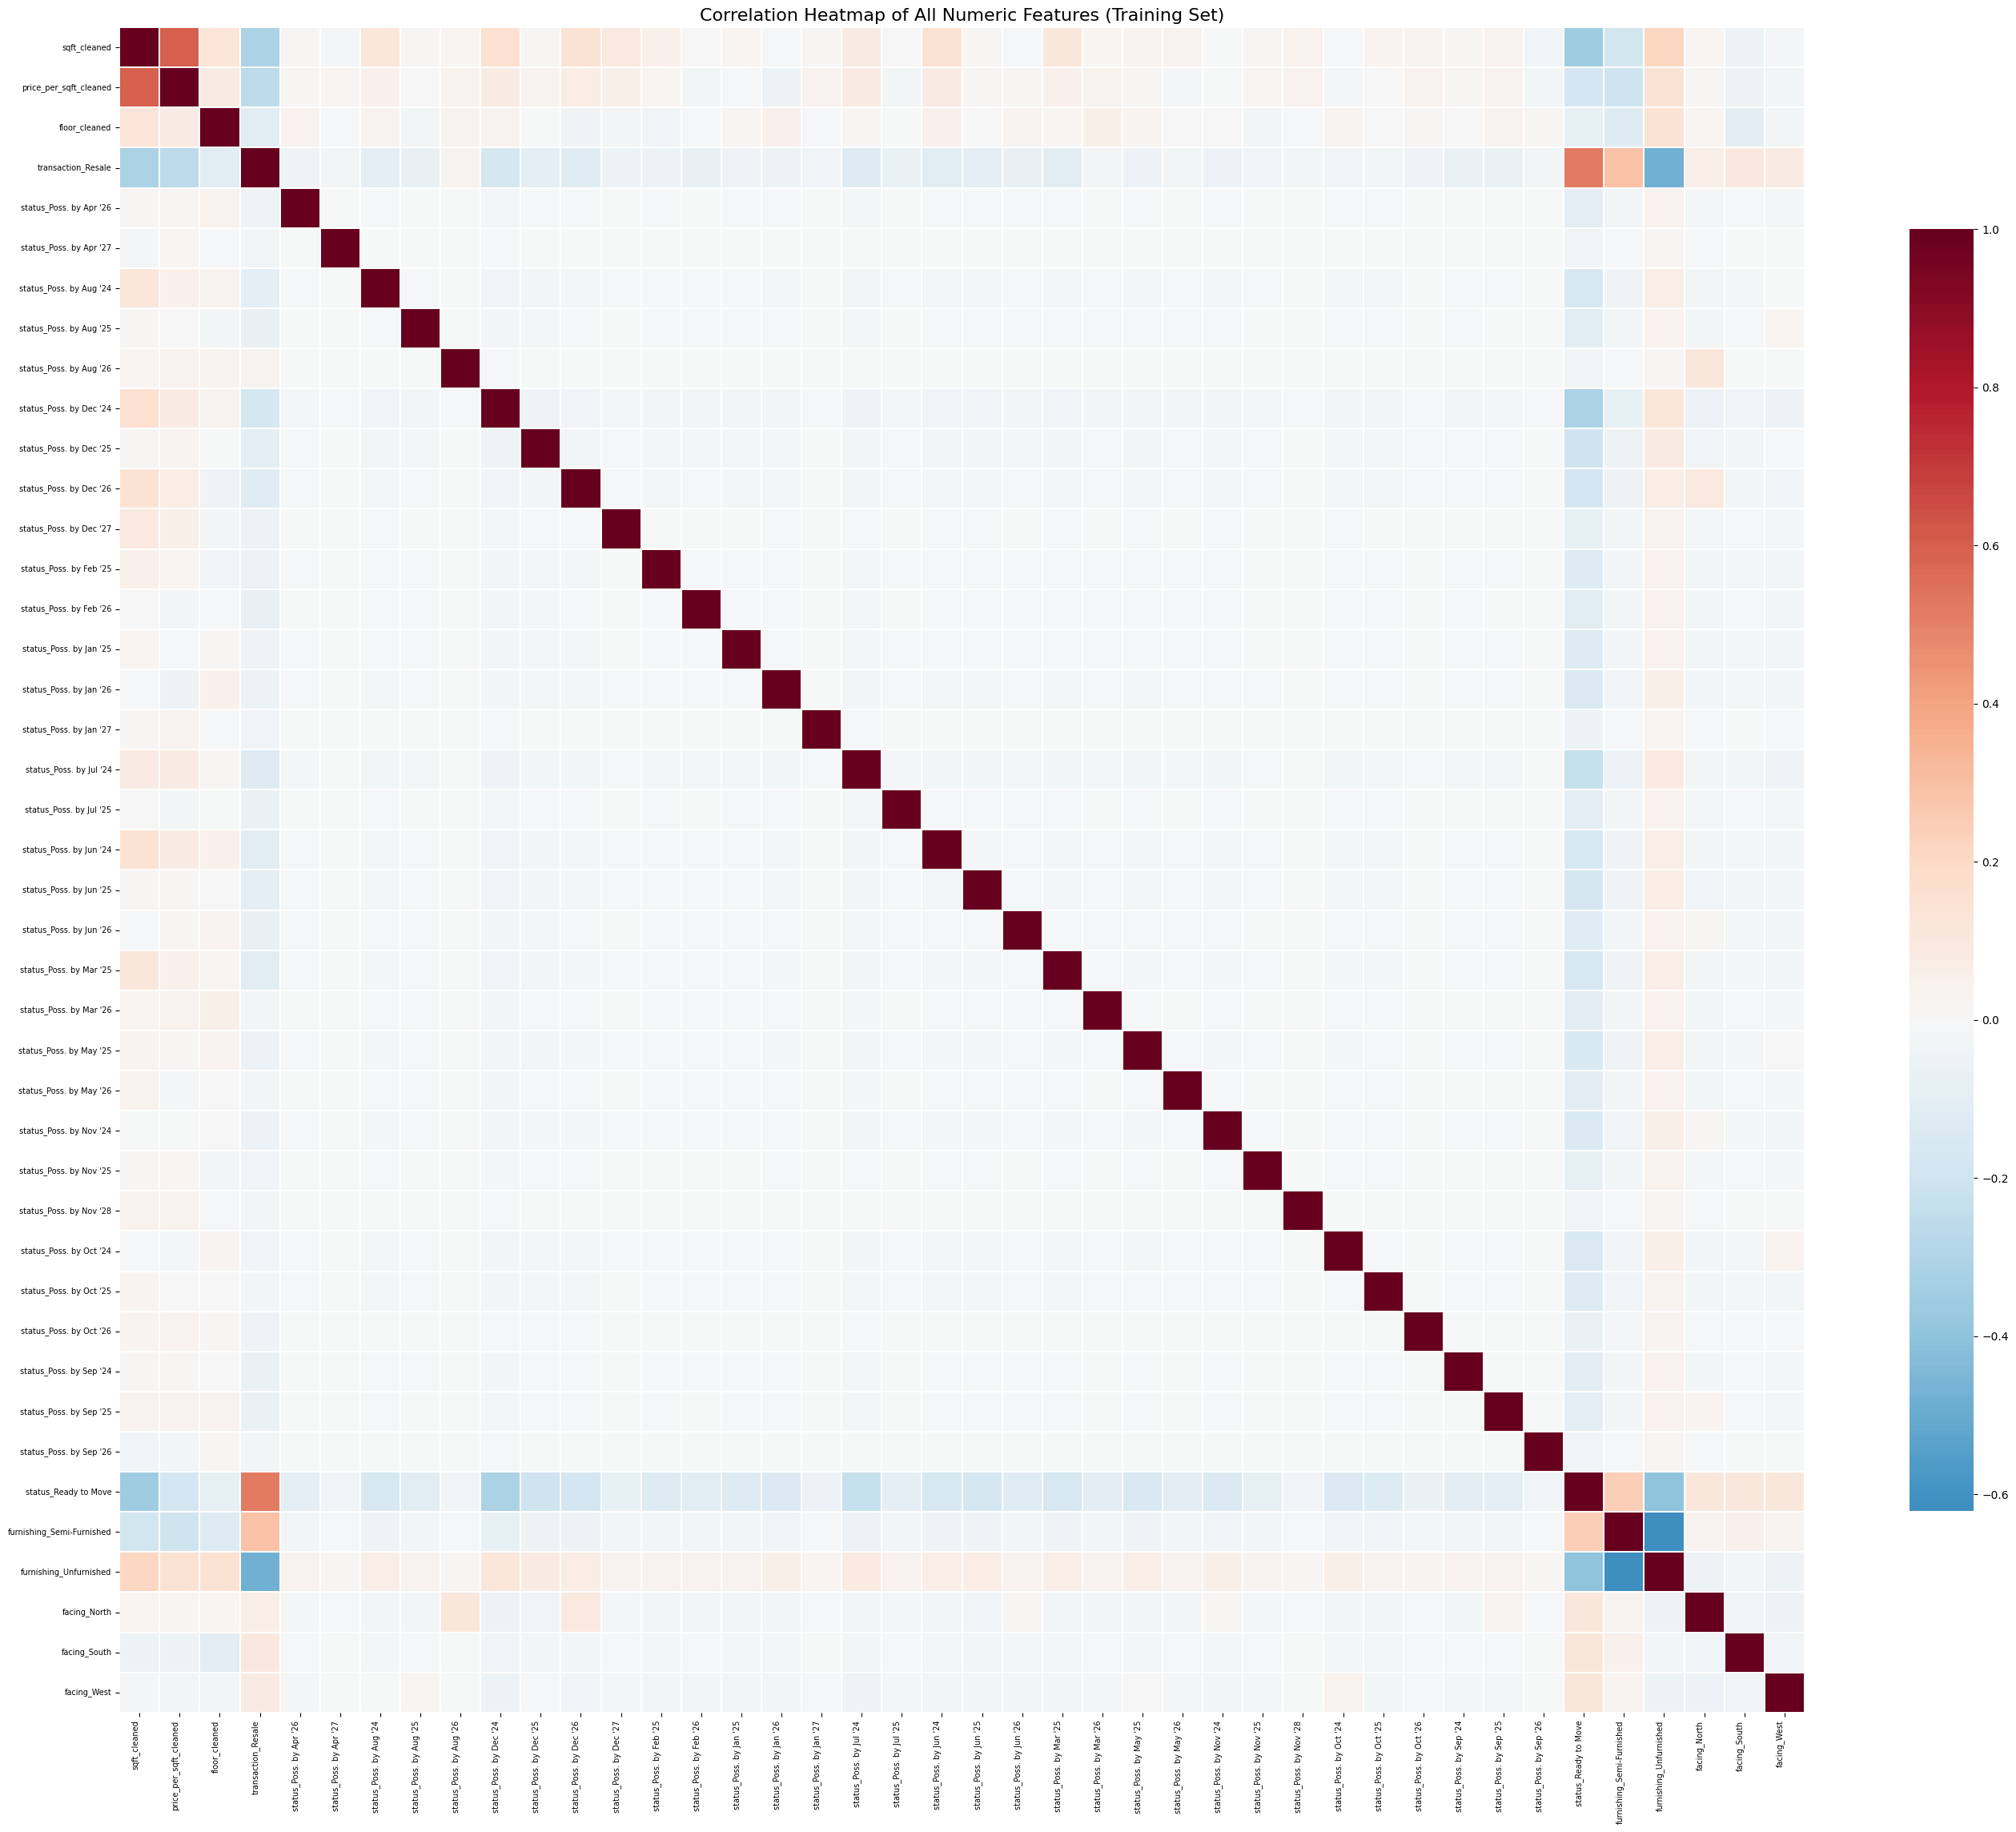

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# اختيار أهم الأعمدة الرقمية (حسب الارتباط مع السعر أو التباين)
# لكننا سنعرض الكل مع تحسين الرؤية
numeric_df = X_train_encoded.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

# ضبط حجم الرسم ليتسع لـ 42 عموداً
plt.figure(figsize=(28, 24))

# رسم heatmap بدون أرقام (لتجنب الفوضى) مع ألوان أكثر تبايناً
sns.heatmap(corr_matrix, 
            annot=False,           # إخفاء الأرقام لتحسين القراءة
            cmap='RdBu_r',         # ألوان حمراء-زرقاء أفضل
            center=0,
            square=True,
            linewidths=0.1,
            cbar_kws={"shrink": 0.7})

# تحسين تسميات المحاور
plt.title('Correlation Heatmap of All Numeric Features (Training Set)', fontsize=16)
plt.xticks(rotation=90, fontsize=7, ha='right')
plt.yticks(fontsize=7)

plt.tight_layout()
plt.show()

Total features: 42
Sample features (first 20): ['sqft_cleaned', 'price_per_sqft_cleaned', 'floor_cleaned', 'transaction_Resale', "status_Poss. by Apr '26", "status_Poss. by Apr '27", "status_Poss. by Aug '24", "status_Poss. by Aug '25", "status_Poss. by Aug '26", "status_Poss. by Dec '24", "status_Poss. by Dec '25", "status_Poss. by Dec '26", "status_Poss. by Dec '27", "status_Poss. by Feb '25", "status_Poss. by Feb '26", "status_Poss. by Jan '25", "status_Poss. by Jan '26", "status_Poss. by Jan '27", "status_Poss. by Jul '24", "status_Poss. by Jul '25"]


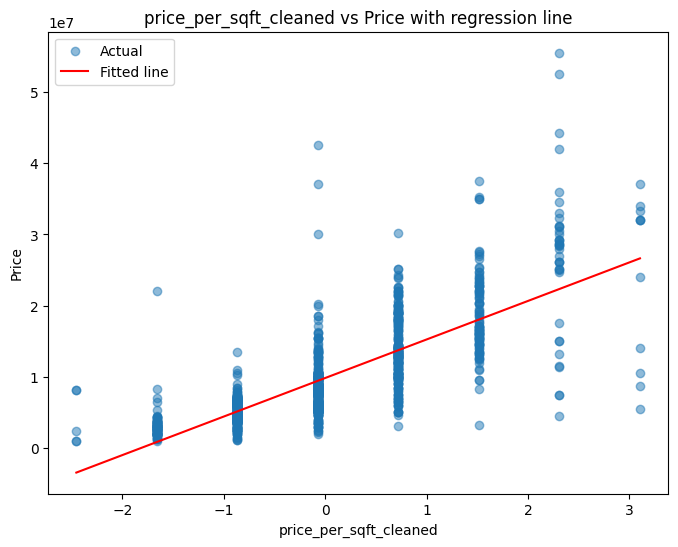

In [66]:
def plot_scatter_input():
    # لا تطبع القائمة الكاملة، فقط عدد الأعمدة
    print(f"Total features: {len(X_train_encoded.columns)}")
    print("Sample features (first 20):", list(X_train_encoded.columns)[:20])
    
    feature = input("Enter exact feature name from the list (or type 'sqft_cleaned' for example): ")
    if feature not in X_train_encoded.columns:
        print(f"Feature '{feature}' not found. Try a simpler one like 'sqft_cleaned'")
        return
    idx = X_train_encoded.columns.get_loc(feature)
    X_feat = X_train_final[:, idx].reshape(-1, 1)
    y = y_train_final
    
    model = NumericalLinearRegression(ridge_lambda=0)
    model.fit(X_feat, y)
    
    x_line = np.linspace(X_feat.min(), X_feat.max(), 100).reshape(-1, 1)
    y_line = model.predict(x_line)
    
    plt.figure(figsize=(8,6))
    plt.scatter(X_feat, y, alpha=0.5, label='Actual')
    plt.plot(x_line, y_line, 'r-', label='Fitted line')
    plt.xlabel(feature)
    plt.ylabel('Price')
    plt.title(f'{feature} vs Price with regression line')
    plt.legend()
    plt.show()

plot_scatter_input()

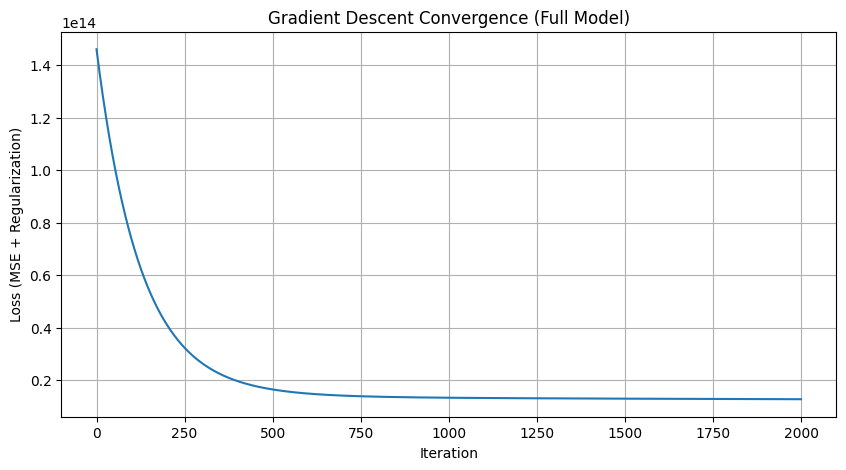

In [68]:
# نموذج الانحدار المتعدد (بدون استيراد)
model_gd = MultipleLinearRegression(learning_rate=0.001, n_iterations=2000,
                                    lasso_lambda=0, ridge_lambda=0)
model_gd.fit(X_train_final, y_train_final)

plt.figure(figsize=(10,5))
plt.plot(model_gd.loss_history)
plt.xlabel('Iteration')
plt.ylabel('Loss (MSE + Regularization)')
plt.title('Gradient Descent Convergence (Full Model)')
plt.grid(True)
plt.show()

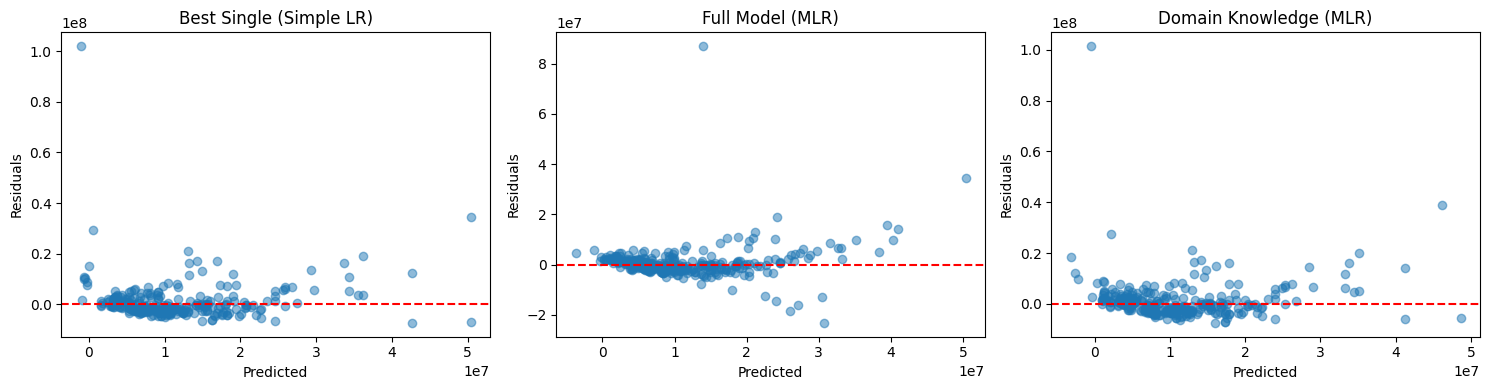

In [69]:
# 1. أفضل متغير (نستخدم النموذج البسيط من الخطوة السابقة)
#    نستخرج أفضل متغير تلقائياً
correlations = X_train_encoded.corrwith(y_train)
best_feature = correlations.abs().idxmax()
idx_best = X_train_encoded.columns.get_loc(best_feature)
X_train_single = X_train_final[:, idx_best].reshape(-1, 1)
X_test_single = X_test_final[:, idx_best].reshape(-1, 1)

model_single = NumericalLinearRegression(ridge_lambda=0)
model_single.fit(X_train_single, y_train_final)
y_pred_single = model_single.predict(X_test_single)
residuals_single = y_test_final - y_pred_single

# 2. النموذج الكامل (استخدم نفس model_gd الذي دربناه قبل قليل)
y_pred_full = model_gd.predict(X_test_final)
residuals_full = y_test_final - y_pred_full

# 3. نموذج المعرفة (Domain Knowledge): اختر 3-4 متغيرات منطقية
domain_features = ['sqft_cleaned', 'furnishing_Unfurnished', 'transaction_Resale']
# تأكد من وجودهم في X_train_encoded
available = [f for f in domain_features if f in X_train_encoded.columns]
idx_domain = [X_train_encoded.columns.get_loc(f) for f in available]
X_train_domain = X_train_final[:, idx_domain]
X_test_domain = X_test_final[:, idx_domain]

model_domain = MultipleLinearRegression(learning_rate=0.001, n_iterations=2000,
                                        lasso_lambda=0, ridge_lambda=0)
model_domain.fit(X_train_domain, y_train_final)
y_pred_domain = model_domain.predict(X_test_domain)
residuals_domain = y_test_final - y_pred_domain

# رسم الـ Residuals جنباً إلى جنب
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(y_pred_single, residuals_single, alpha=0.5)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Best Single (Simple LR)')

axes[1].scatter(y_pred_full, residuals_full, alpha=0.5)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Full Model (MLR)')

axes[2].scatter(y_pred_domain, residuals_domain, alpha=0.5)
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Residuals')
axes[2].set_title('Domain Knowledge (MLR)')

plt.tight_layout()
plt.show()

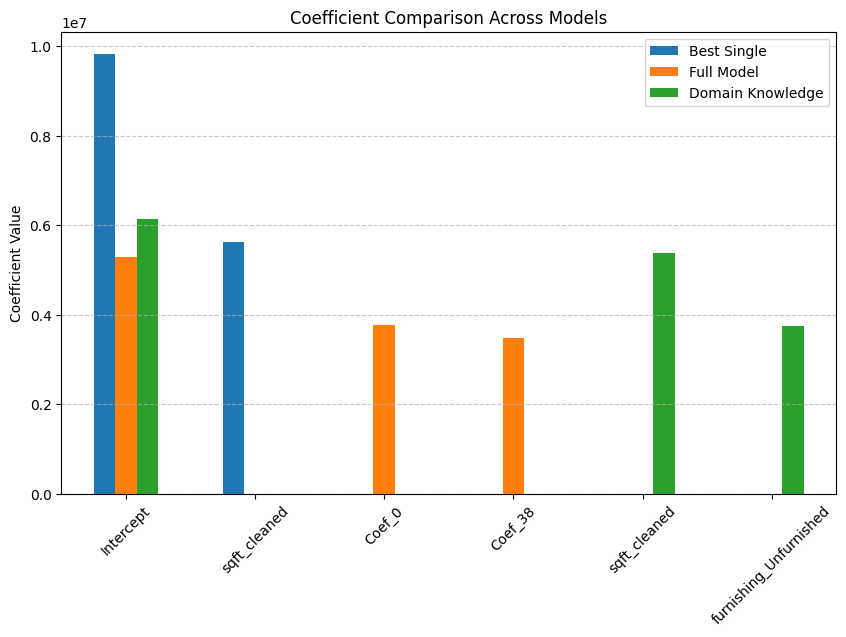

In [70]:
# استخراج المعاملات
# Best single: intercept and slope
intercept_single = model_single.theta[0][0]
slope_single = model_single.theta[1][0]

# Full model: intercept + جميع المعاملات (نأخذ أعلى 3 قيم مطلقة من حيث التأثير)
full_coef_names = ['Intercept'] + [f"Coef_{i}" for i in range(len(model_gd.theta)-1)]
full_coef_vals = [model_gd.theta[0][0]] + model_gd.theta[1:].flatten().tolist()
# احسب القيم المطلقة (بدون intercept) لإيجاد أهم المعاملات
abs_vals = np.abs(full_coef_vals[1:])
top3_indices = np.argsort(abs_vals)[-3:][::-1]   # أعلى 3
top3_names = [full_coef_names[i+1] for i in top3_indices]
top3_vals = [full_coef_vals[i+1] for i in top3_indices]

# Domain model coefficients
domain_coef_names = ['Intercept'] + available
domain_coef_vals = [model_domain.theta[0][0]] + model_domain.theta[1:].flatten().tolist()

# نرسم المقارنة: intercept + best single slope + أهم 2 من full + أهم 2 من domain
# (لتجنب كثافة الأعمدة نختار مجموعة محدودة)
compare_names = ['Intercept', best_feature] + top3_names[:2] + available[:2]
compare_single = [intercept_single, slope_single] + [0,0,0,0]
compare_full = [full_coef_vals[0], 0] + top3_vals[:2] + [0,0]
compare_domain = [domain_coef_vals[0], 0] + [0,0] + domain_coef_vals[1:3]

# إنشاء DataFrame للمقارنة
import pandas as pd
df_compare = pd.DataFrame({
    'Best Single': compare_single[:len(compare_names)],
    'Full Model': compare_full[:len(compare_names)],
    'Domain Knowledge': compare_domain[:len(compare_names)]
}, index=compare_names)

# رسم الأعمدة
df_compare.plot(kind='bar', figsize=(10,6))
plt.title('Coefficient Comparison Across Models')
plt.ylabel('Coefficient Value')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()